# Matching-engine benchmarks — the measured difference

Two limit-order-book implementations with identical, differentially-fuzzed
semantics: **MapBook** (`std::map` price levels, `std::list` FIFO queues — the
readable reference and correctness oracle) and **FastBook** (contiguous price
ladder, object pool, intrusive doubly-linked FIFO queues). This notebook reads
`results/benchmarks.csv` — produced by `lob_bench` on the machine documented
below — and turns it into the plots and tables the README quotes.

**Methodology, before any numbers:** single thread pinned to one core; a full
warmup replay excluded from every statistic; throughput measured with one clock
around the whole replay (no per-op timing distortion); latency measured with
TSC reads around every operation (~5–10ns rdtsc-pair cost *included*; Windows
`steady_clock` at 100ns granularity would quantise the percentiles, which is
why TSC); three repetitions per configuration, aggregated by **median** with
min–max shown; identical op streams for both engines. Hardware: AMD Ryzen 7
7730U (laptop, Windows 11, desktop apps running) — a consumer machine, not an
isolated rig, and the tail numbers say so honestly.

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ASSETS = Path("..") / "assets"
ASSETS.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../results/benchmarks.csv")
df["flow_kind"] = df.flow.str.replace(r"-seed\d+", "", regex=True)

agg = df.groupby(["impl", "flow_kind"]).agg(
    runs=("throughput_mops", "size"),
    tput_med=("throughput_mops", "median"),
    tput_min=("throughput_mops", "min"),
    tput_max=("throughput_mops", "max"),
    p50=("p50_ns", "median"), p90=("p90_ns", "median"),
    p99=("p99_ns", "median"), p999=("p999_ns", "median"),
    max_ns=("max_ns", "median"),
)
agg.round(1)

runs  tput_med  tput_min  tput_max    p50    p90    p99  \
impl     flow_kind                                                            
FastBook lobster       3      10.7       9.9      11.9   60.0  160.0  380.0   
         synthetic     9      12.2       3.0      16.3   50.0  180.0  641.0   
MapBook  lobster       3       7.5       6.8       7.5  100.0  180.0  310.0   
         synthetic     9       8.2       4.9       9.3   90.0  330.0  951.0   

                      p999     max_ns  
impl     flow_kind                     
FastBook lobster     751.0   344804.0  
         synthetic  2144.0  1681622.0  
MapBook  lobster     671.0   738502.0  
         synthetic  3266.0  1343109.0

## Throughput

Median of the repetitions, with min–max whiskers. The synthetic flow is one
million operations per run (55/25/10/10 submit/cancel/market/reduce around a
random-walking mid); the LOBSTER flow replays the full AMZN 2012-06-21 sample
day — 261k operations dominated by submissions and cancellations, as real
feeds are.

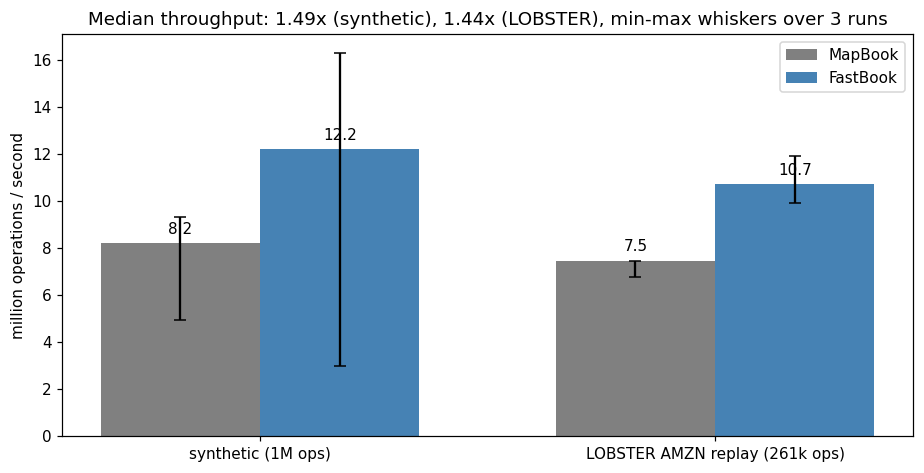

In [2]:
flows = ["synthetic", "lobster"]
impls = ["MapBook", "FastBook"]
colors = {"MapBook": "gray", "FastBook": "steelblue"}

fig, ax = plt.subplots(figsize=(8.5, 4.4))
width = 0.35
x = np.arange(len(flows))
for k, impl in enumerate(impls):
    med = [agg.loc[(impl, f), "tput_med"] for f in flows]
    lo = [med[i] - agg.loc[(impl, f), "tput_min"] for i, f in enumerate(flows)]
    hi = [agg.loc[(impl, f), "tput_max"] - med[i] for i, f in enumerate(flows)]
    bars = ax.bar(x + (k - 0.5) * width, med, width, yerr=[lo, hi], capsize=4,
                  label=impl, color=colors[impl])
    for bar, value in zip(bars, med):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.4, f"{value:.1f}",
                ha="center", fontsize=10)
ax.set_xticks(x, ["synthetic (1M ops)", "LOBSTER AMZN replay (261k ops)"])
ax.set_ylabel("million operations / second")
speed_syn = agg.loc[("FastBook", "synthetic"), "tput_med"] / agg.loc[("MapBook", "synthetic"), "tput_med"]
speed_lob = agg.loc[("FastBook", "lobster"), "tput_med"] / agg.loc[("MapBook", "lobster"), "tput_med"]
ax.set_title(f"Median throughput: {speed_syn:.2f}x (synthetic), {speed_lob:.2f}x (LOBSTER), "
             "min-max whiskers over 3 runs")
ax.legend()
fig.tight_layout()
fig.savefig(ASSETS / "throughput.png", bbox_inches="tight")
plt.show()

## Latency percentiles — where the two designs actually differ

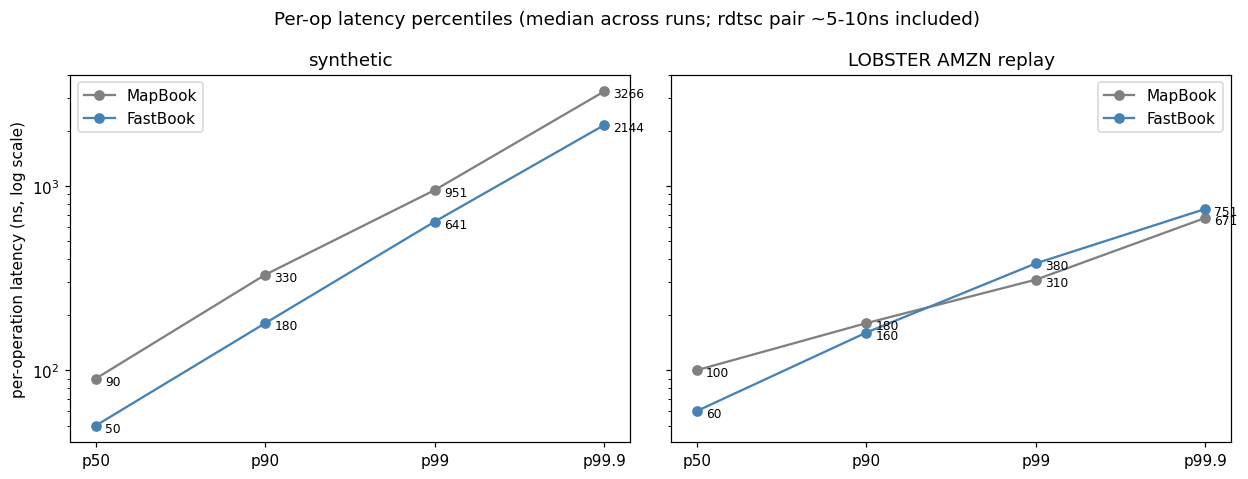

In [3]:
percentiles = ["p50", "p90", "p99", "p999"]
labels = ["p50", "p90", "p99", "p99.9"]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
for ax, flow in zip(axes, flows):
    for impl in impls:
        values = [agg.loc[(impl, flow), p] for p in percentiles]
        ax.plot(labels, values, marker="o", label=impl, color=colors[impl])
        for lx, v in zip(labels, values):
            ax.annotate(f"{v:.0f}", (lx, v), textcoords="offset points",
                        xytext=(6, -4), fontsize=8)
    ax.set_yscale("log")
    ax.set_title("synthetic" if flow == "synthetic" else "LOBSTER AMZN replay")
    ax.legend()
axes[0].set_ylabel("per-operation latency (ns, log scale)")
fig.suptitle("Per-op latency percentiles (median across runs; rdtsc pair ~5-10ns included)")
fig.tight_layout()
fig.savefig(ASSETS / "latency.png", bbox_inches="tight")
plt.show()

## Reading the numbers honestly

**Where FastBook wins.** Median (p50) latency roughly halves — ~50ns vs ~90ns
on synthetic flow, ~60ns vs ~100ns on the replay — and median throughput is
about 1.4–1.5x on both flows. This is the pool + intrusive-list + ladder
design doing what it promises for the *common* case: no allocation, no tree
walk, one array index to the level.

**Where it doesn't.** On the LOBSTER replay the FastBook *tail* (p99/p99.9) is
slightly WORSE than MapBook's. That is not noise — it is the ladder's known
weakness on sparse books, measured. AMZN ticks in $0.0001 on a ~$224 stock, so
occupied price levels sit hundreds of empty ticks apart; when the best level
empties, the ladder scans linearly for the next occupied slot while the
`std::map` just steps to its neighbour. Dense synthetic books (levels one tick
apart) never show this; a wide-tick real book does. The standard fix — a
bitmap summary of occupied levels scanned with tzcnt, giving O(64-ticks) skips
— is the named next step rather than silently absent.

**Tail spikes.** Both engines show rare max latencies in the 0.5–10ms range:
page faults, allocator growth, and OS preemption on a desktop Windows laptop.
An isolated-core Linux rig with locked pages and a warmed allocator is the
right environment for citing tail numbers; this repo's claim is the *relative*
comparison under identical conditions, not absolute HFT figures.

**And the number that matters most is not on a chart:** every operation stream
used here produces identical fills, identical return values, and identical
book snapshots on both engines — enforced continuously by the differential
fuzz suite (25 seeds x 20k ops plus a 200k-op session per CI run, under
ASan/UBSan). Fast numbers from a wrong book are worthless; correctness is the
benchmark's precondition, not its afterthought.